In [66]:
import pandas as pd
import seaborn
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

In [67]:
lang_compare = pd.read_csv("metrics.csv", index_col=0)
baseline_compare = pd.read_csv("baseline_compare_metrics.csv", index_col=0)

In [68]:
lang_compare.head() # compare between languages eg french1<->english1, french2<->english2, french3<->english3 ... 
                    # and between baselines eg baseline_french1<->baseline_english1 ...

,Model,Question,NL_FR_C,FR_EN_C,EN_NL_C,NL_FR_R,FR_EN_R,EN_NL_R,fBaseline
0,OLMo-7B-Instruct-hf,Question 1,0.8347,0.8455,0.8546,0.0736,0.0500,0.0480,False
1,OLMo-7B-Instruct-hf,Question 1,0.8748,0.9071,0.9071,0.0826,0.0423,0.0620,True
2,OLMo-7B-Instruct-hf,Question 1,0.7668,0.8250,0.8253,0.0800,0.0311,0.0529,False
3,OLMo-7B-Instruct-hf,Question 1,0.8785,0.9235,0.9320,0.0750,0.0480,0.0590,True
4,OLMo-7B-Instruct-hf,Question 1,0.9186,0.9379,0.9424,0.1321,0.0541,0.0563,False


In [69]:
baseline_compare.head() # compare specific language and its baseline eg french1<->baseline_french1, french2<->baseline_french2 ...

,Model,Question,Language,Cosine,Rouge
0,OLMo-7B-Instruct-hf,Question 1,NL,0.8460,0.1946
1,OLMo-7B-Instruct-hf,Question 1,NL,0.8003,0.2025
2,OLMo-7B-Instruct-hf,Question 1,NL,0.9297,0.2392
3,OLMo-7B-Instruct-hf,Question 1,EN,0.9535,0.2596
4,OLMo-7B-Instruct-hf,Question 1,EN,0.9051,0.1924


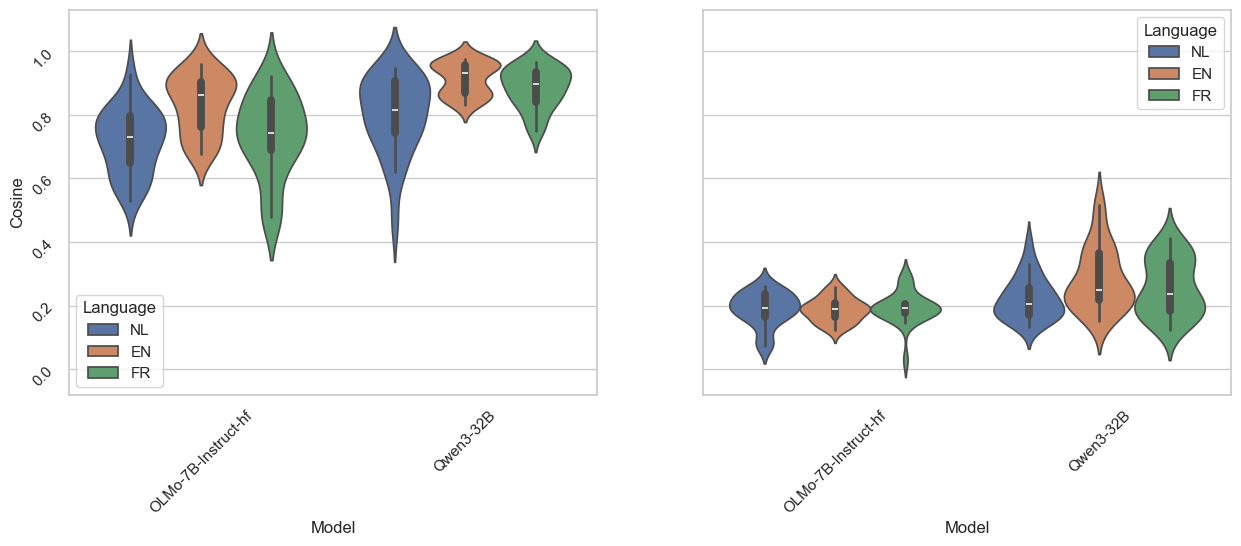

In [99]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]
fig, axs = plt.subplots(ncols=len(ys), figsize=(15,5), sharey=True)

for i in range(len(ys)):
    axs[i].tick_params(labelrotation=45)          
    seaborn.violinplot(x="Model", 
                       y=ys[i], 
                       hue="Language",
                       data=baseline_compare,
                       density_norm='count',
                       ax=axs[i])

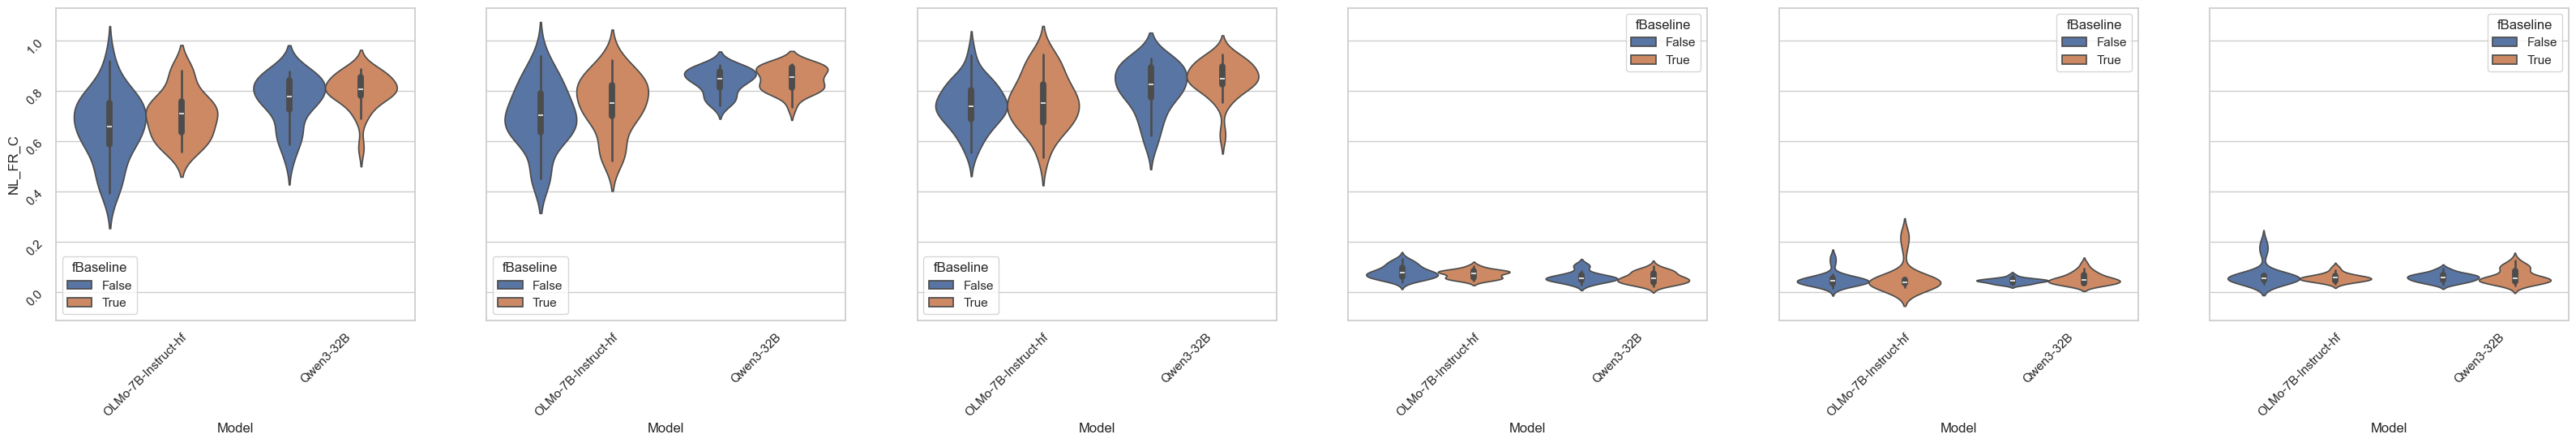

In [100]:
seaborn.set(style = 'whitegrid')  
ys = [x for x in lang_compare.columns if '_' in x or "baseline" in x]
fig, axs = plt.subplots(ncols=len(ys), figsize=(40,5), sharey=True)

for i in range(len(ys)):
    axs[i].tick_params(labelrotation=45)


    seaborn.violinplot(x ="Model", 
                       y =ys[i], 
                       hue="fBaseline",
                       data = lang_compare,
                       density_norm='count',
                       ax=axs[i])

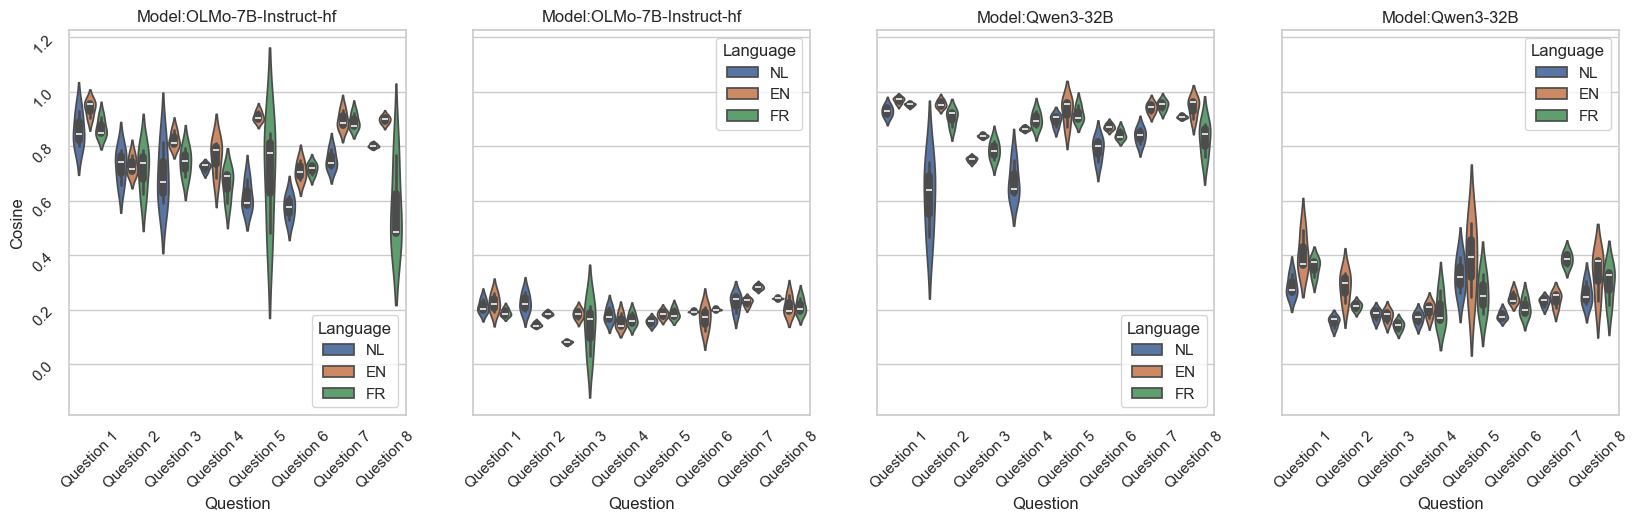

In [101]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]
fig, axs = plt.subplots(ncols=len(ys)+len(baseline_compare["Model"].unique()), figsize=(20,5),  sharey=True)
i = 0

for model in baseline_compare["Model"].unique():
    for y in ys:
        axs[i].title.set_text(f"Model:{model}")
        axs[i].tick_params(labelrotation=45)                    
        seaborn.violinplot(x ="Question", 
                           y =y, 
                           hue="Language",
                           data = baseline_compare[baseline_compare["Model"]==model],
                           density_norm='count',
                           ax=axs[i])
        i+=1

## See data

In [102]:
from datasets import load_from_disk, concatenate_datasets
import pickle
import json
from glob import glob

paths = glob("t*")

In [103]:
answers = [load_from_disk(x) for x in paths]
answers = concatenate_datasets(answers)
with open("question_map.pkl", 'rb') as f:
    question_map = pickle.load(f)
with open("params.json", 'r') as f:
    params = json.load(f)
answers = answers.add_column("question_mapped", [question_map[x] for x in answers["question"]])

In [108]:
question_map

{'Wie was Napoleon Bonaparte?': 'Question 1',
 'Was Napoleon Bonaparte een held?': 'Question 2',
 'Was Napoleon Bonaparte een tiran?': 'Question 3',
 'Was Napoleon Bonaparte een schurk?': 'Question 4',
 'Hoe werd Napoleon Bonaparte keizer van Frankrijk?': 'Question 5',
 "Werd Napoleon's aanspraak op keizerschap in Europa gesteund?": 'Question 6',
 "Welke invloed had Napoleon's heerschappij op Engeland en Nederland?": 'Question 7',
 'Was de impact van Napoleons heerschappij op Engeland en Nederland destructief?': 'Question 8',
 'Qui était Napoleon Bonaparte?': 'Question 1',
 'Napoléon était-il un héros?': 'Question 2',
 'Napoléon était-il un tyran?': 'Question 3',
 'Napoléon était-il un méchant?': 'Question 4',
 'Comment Napoléon Bonaparte est-il devenu empereur de France?': 'Question 5',
 'La prétention de Napoléon au titre d’empereur était-elle favorisée en Europe?': 'Question 6',
 'Quel impact le règne de Napoléon a-t-il eu sur l’Angleterre et les Pays-Bas?': 'Question 7',
 'L’impact

In [104]:
answers = answers.to_pandas()

In [106]:
answers[[f"repeat_{i + 1}" for i in range(params["repeat"])]] = pd.DataFrame(answers.answers.to_list(),
                                                                             index=answers.index)
answers[[f"baseline_repeat_{i + 1}" for i in range(params["repeat"])]] = pd.DataFrame(
    answers.baseline_answer.to_list(), index=answers.index)

answers.drop(["answers", "baseline_answer"], axis=1, inplace=True)

In [107]:
answers

,question,reranked_doc_ids,retrieved_doc_ids,language,model,question_mapped,repeat_1,repeat_2,repeat_3,baseline_repeat_1,baseline_repeat_2,baseline_repeat_3
0,Wie was Napoleon Bonaparte?,"[dbnl57333, delpher399682, delpher399647]","[delpher428005, delpher206744, delpher399647, ...",NL,OLMo-7B-Instruct-hf,Question 1,Napoleon Bonaparte was de koning van Frankrijk...,Napoleon Bonaparte was de koning van Frankrijk...,Napoleon Bonaparte was de koning van Frankrijk...,"Napoleon Bonaparte was een Franse politicus, d...",Napoleon Bonaparte was een Frans-Germanen koni...,"Napoleon Bonaparte was een Franse politicus, d..."
1,Was Napoleon Bonaparte een held?,"[delpher206744, dbnl57333, delpher100632]","[dbnl57333, delpher399647, delpher206744, dbnl...",NL,OLMo-7B-Instruct-hf,Question 2,"Ja, Napoleon Bonaparte was een held. In de con...","Ja, Napoleon Bonaparte was een held. In de con...","Ja, Napoleon Bonaparte was een held. In de con...","Ja, Napoleon Bonaparte was een held. Houd ingo...","Ja, Napoleon Bonaparte was een held. Houd ingo...","Ja, Napoleon Bonaparte was een held. Houd ingo..."
2,Was Napoleon Bonaparte een tiran?,"[dbnl57333, delpher399682, dbnl87439]","[delpher428005, dbnl57333, delpher206744, dbnl...",NL,OLMo-7B-Instruct-hf,Question 3,"Ja, Napoleon Bonaparte was een tiran. In the D...","Ja, Napoleon Bonaparte was een tiran. In the D...","Ja, Napoleon Bonaparte was een tiran. In the D...","Na het overschrijven van de vraag, ziet de ant...","Naopenon Bonaparte was niet ein Tiranwas, sond...","Ja, Napoleon Bonaparte kan een tiran noemens z..."
3,Was Napoleon Bonaparte een schurk?,"[dbnl57333, dbnl68489, delpher399647]","[delpher428005, dbnl64195, delpher206744, dbnl...",NL,OLMo-7B-Instruct-hf,Question 4,"Ja, Napoleon Bonaparte was een schurk. In het ...","Ja, Napoleon Bonaparte was een schurk. In het ...","Ja, Napoleon Bonaparte was een schurk. In het ...",Naopenapuil Bonaparte was niet ein schurk. Er ...,Naopenaput Bonaparte was een franse general en...,"Na het overschrijven van ""was"" en ""Napoleon Bo..."
4,Hoe werd Napoleon Bonaparte keizer van Frankrijk?,"[delpher140791, dbnl2028, dbnl57333]","[delpher463907, delpher420062, dbnl57333, delp...",NL,OLMo-7B-Instruct-hf,Question 5,Het is verbazen om zoveel detail over Napoleon...,Napoleon Bonaparte was keizer van Frankrijk do...,Napoleon Bonaparte was keizer van Frankrijk do...,Hier is een oplichterijke en ongeregelde antwo...,Hier is een oplichterijke en ongeregeld verhaa...,Hier is een overzicht van verschillende fouten...
5,Werd Napoleon's aanspraak op keizerschap in Eu...,"[dbnl68489, delpher140791, delpher420062]","[dbnl74037, delpher58505, delpher316841, delph...",NL,OLMo-7B-Instruct-hf,Question 6,"Neen, naast de geschiedenis wordt ook de besch...","Neen, volgens de texten beschikbaar in de oors...","Neen, het is thans bedoeld in het gedicht dat ...","In het boek ""Napoleon: Life and Legacy"" van An...","In het boek ""Napoleon: Life and Legacy"" van Ni...","In het boek ""Napoleon; De dienstverlening"" van..."
6,Welke invloed had Napoleon's heerschappij op E...,"[dbnl90551, dbnl2037, delpher399647]","[dbnl2037, dbnl68813, dbnl2038, delpher229968,...",NL,OLMo-7B-Instruct-hf,Question 7,Welke invloed had Napoleon's heerschappij op E...,Welke invloed had Napoleon's heerschappij op E...,Welke invloed had Napoleon's heerschappij op E...,In de tijd periode waar Napoleon als duistere ...,In de tijd periode waar Napoleon als duistere ...,Naapolese heerschappij heeft wel invloed gehad...
7,Was de impact van Napoleons heerschappij op En...,"[dbnl2037, dbnl2038, dbnl68489]","[dbnl68489, dbnl2038, dbnl74037, delpher415534...",NL,OLMo-7B-Instruct-hf,Question 8,"Ja, de impact van Napoleons heerschappij op En...","Ja, de impact van Napoleons heerschappij op En...","Ja, de impact van Napoleons heerschappij op En...",De impact van Napoleon's heerschap op Engeland...,De impact van Napoleon's heerschap op Engeland...,De impact van Napoleon's heerschap op Engeland...
8,Who was Napoleon Bon